<a href="https://colab.research.google.com/github/sonjoy1s/OIBSIP/blob/main/Unemployment_in_IndiaTask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [197]:
df = pd.read_csv("/content/Unemployment in India.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [199]:
df.isna().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [200]:
df.drop(columns=[' Frequency'],axis=1,inplace=True)

In [201]:
df.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,5.17,12256762.0,44.68,Rural


In [202]:
df[' Date'] = pd.to_datetime(df[' Date'].str.strip(), format='%d-%m-%Y')

In [203]:
type(df[' Date'].values.dtype)

numpy.dtypes.DateTime64DType

In [204]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,NaN,NaN,NaN,2019-12-12 18:36:58.378378496,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


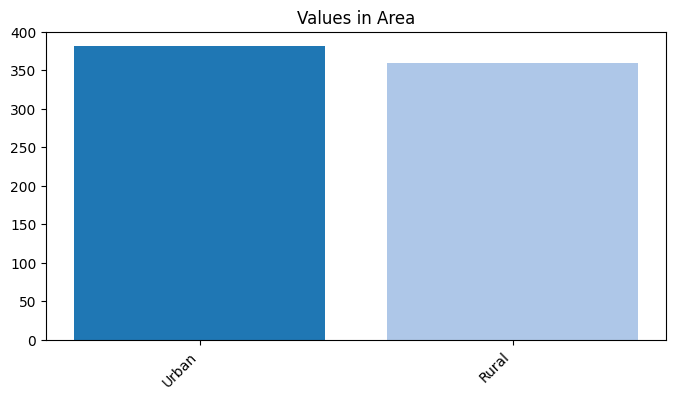

In [205]:
plt.figure(figsize=(8,4))
plt.bar(x=df['Area'].value_counts().keys(),
            height=df['Area'].value_counts().values,
            color=plt.cm.tab20.colors)
plt.title(f'Values in Area')
plt.xticks(rotation=45, ha='right')
plt.show()

In [206]:
df.columns = df.columns.str.strip()
df['Estimated Unemployment Rate (%)'] = df['Estimated Unemployment Rate (%)'].fillna(df['Estimated Unemployment Rate (%)'].mean())

In [207]:
df.columns = df.columns.str.strip()
X = df.drop(columns=['Estimated Unemployment Rate (%)'],axis=1)
y = df['Estimated Unemployment Rate (%)']

In [208]:
numerical_cols = X.select_dtypes(include=np.number).columns
print(numerical_cols)

categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Estimated Employed', 'Estimated Labour Participation Rate (%)'], dtype='object')
Index(['Region', 'Area'], dtype='object')


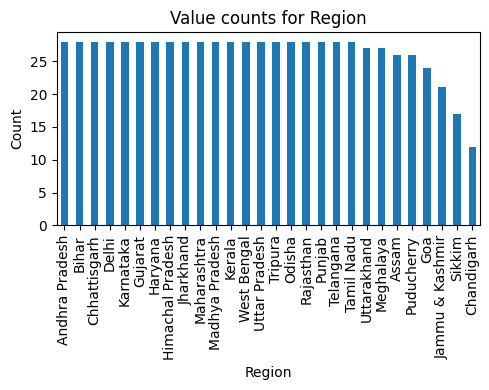

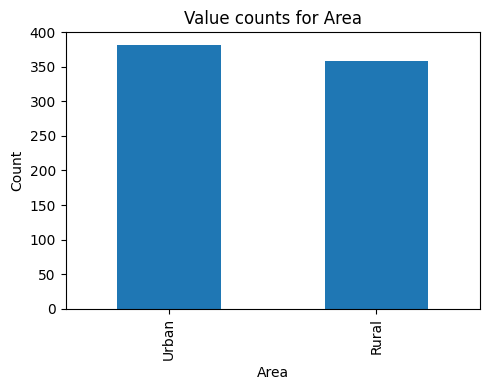

In [209]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [210]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [211]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [212]:
#Combine numerical and categorical

from sklearn.compose import ColumnTransformer
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [213]:
data_combined = X.copy()
data_combined['target'] = y

data_cleaned = data_combined.dropna()

X_clean = data_cleaned.drop(columns=['target'])
y_clean = data_cleaned['target']

X_train,X_test, y_train, y_test = train_test_split(X_clean,y_clean, test_size = 0.25 , random_state=42)

In [214]:
print(X_train.shape)
print(X_test.shape)

# duplicate check
import pandas as pd

train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

duplicates = pd.merge(train_df, test_df, how='inner')
print("Duplicate samples:", len(duplicates))

(555, 5)
(185, 5)
Duplicate samples: 0


In [215]:
# base Learner
from xgboost import XGBRegressor # Import XGBRegressor
from sklearn.linear_model import LinearRegression # Import LinearRegression
lr = LinearRegression() # Replaced LogisticRegression with LinearRegression
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
xgb = XGBRegressor(random_state=42) # Removed deprecated/irrelevant parameters for regression

In [216]:
voting_reg = VotingRegressor(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)

    ]
)

In [217]:
#Stacking

stacking_reg = StackingRegressor(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)
    ]
)

In [218]:
model_to_train = {
    'Linear Regression':lr, # Updated name from Logistic Regression
    'Decision Tree':dt,
    'Random Forest':rf,
    'Gradient Boosting':gb,
    'XGBoost':xgb,
    'Voting Regressor':voting_reg, # Updated name from Voting Classifier
    'Stacking Regressor':stacking_reg # Updated name from Stacking Classifier
}

In [219]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd # Import pandas if needed elsewhere, but qcut is removed

results = []

# The target variable y is continuous for a regression problem, so no binning or encoding is needed.

for model_name, model in model_to_train.items():
    print(f"--- Training and Evaluating {model_name} ---")

    pipe = Pipeline(
        steps=[
            ('combine', Combine_pipe),
            ('model', model)
        ]
    )

    # Train using the original continuous y_train
    pipe.fit(X_train, y_train)

    # Predict continuous values
    y_pred = pipe.predict(X_test)

    # Use regression metrics, comparing against the original continuous y_test
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model_name': model_name,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2_score': r2
    })

    print(f"MSE for {model_name}: {mse:.4f}")
    print(f"RMSE for {model_name}: {rmse:.4f}")
    print(f"MAE for {model_name}: {mae:.4f}")
    print(f"R2 Score for {model_name}: {r2:.4f}\n")

print("\n--- All Model Results Summary ---")
for res in results:
    print(f"Model: {res['model_name']}, RMSE: {res['rmse']:.4f}, R2 Score: {res['r2_score']:.4f}")

--- Training and Evaluating Linear Regression ---
MSE for Linear Regression: 92.1413
RMSE for Linear Regression: 9.5990
MAE for Linear Regression: 5.7462
R2 Score for Linear Regression: 0.3306

--- Training and Evaluating Decision Tree ---
MSE for Decision Tree: 57.9430
RMSE for Decision Tree: 7.6120
MAE for Decision Tree: 4.1804
R2 Score for Decision Tree: 0.5790

--- Training and Evaluating Random Forest ---
MSE for Random Forest: 42.9197
RMSE for Random Forest: 6.5513
MAE for Random Forest: 3.7470
R2 Score for Random Forest: 0.6882

--- Training and Evaluating Gradient Boosting ---
MSE for Gradient Boosting: 44.0967
RMSE for Gradient Boosting: 6.6405
MAE for Gradient Boosting: 4.3161
R2 Score for Gradient Boosting: 0.6796

--- Training and Evaluating XGBoost ---
MSE for XGBoost: 31.5821
RMSE for XGBoost: 5.6198
MAE for XGBoost: 3.4899
R2 Score for XGBoost: 0.7706

--- Training and Evaluating Voting Regressor ---
MSE for Voting Regressor: 41.5727
RMSE for Voting Regressor: 6.4477
MAE